# Track B — 고위험 지역 분류 (IMD 3분위 위험등급)


| 항목 | 내용 |
|------|------|
| 분석 유형 | 지도학습 — 다중 분류 (Supervised Multi-class Classification) |
| 타겟(Y) | IMD 3분위 위험등급 — `고위험 / 중위험 / 저위험` (각 140개 행정동, 균형 클래스) |
| 데이터 | `df_analysis.csv` (피처) + `df_criteria.csv` (IMD 레이블) 병합 → 420개 행정동 |
| 모델 | Logistic Regression · SVM (RBF) · Random Forest · XGBoost |
| 분석 순서 | ① 8:2 분할 후 기본 모델 비교 → ② StratifiedKFold-5 CV → ③ GridSearchCV 튜닝 |
| CV 전략 | StratifiedKFold(5) — 클래스 비율 균형 보장 |
| 평가 지표 | Macro F1 · Precision · Recall · ROC-AUC (OvR) · 3×3 Confusion Matrix |

---
## 0. 환경 설정 및 데이터 로드

In [46]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold, cross_validate,
    GridSearchCV, learning_curve, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    make_scorer, roc_curve, auc
)
from xgboost import XGBClassifier


# 한글 폰트
KOREAN_FONTS = [
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
]
for fpath in KOREAN_FONTS:
    import os
    if os.path.exists(fpath):
        fm.fontManager.addfont(fpath)
        korean_name = fm.FontProperties(fname=fpath).get_name()
        plt.rcParams['font.family'] = [korean_name, 'DejaVu Sans']
        break

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 120

# 재현성을 위해서 SEED 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [47]:
# 데이터 로드 및 병합
df_feat = pd.read_csv('data/df_analysis.csv', encoding='utf-8-sig')
df_imd = pd.read_csv('data/df_criteria.csv',  encoding='utf-8-sig')

# 행정동코드 기준 inner join — 위험등급 레이블이 없는 행 제외
df = pd.merge(
    df_feat,
    df_imd[['행정동코드', '위험등급']],
    on='행정동코드', how='inner'
)

ID_COLS = ['행정동코드', '행정동명', '시군구명', '자치구명',
           '연도', '총인구수', '65세이상인구', '독거노인수_2018']

FEAT_COLS = [
    '고령화율',
    '고령화율_변화',
    '독거노인비율',
    '비율_75-79세',
    '비율_80-84세',
    '비율_85세이상',
    '인프라갭',
    '포화도',
    '시설수',
    '수요공급갭지수',
]

TARGET = '위험등급'

# 클래스 순서 고정: 저위험=0, 중위험=1, 고위험=2
CLASS_ORDER = ['저위험', '중위험', '고위험']
df[TARGET] = pd.Categorical(df[TARGET], categories=CLASS_ORDER, ordered=True)

X_all = df[FEAT_COLS].copy()
y_all = df[TARGET].copy()
meta = df[ID_COLS].copy()

# 기존의 420개의 행정동이 제대로 분배되었는지 확인
print(f'병합 후 행정동 수: {len(df)}개')
print(f'피처 수: {len(FEAT_COLS)}개')

# 제대로 분류되어 있는지 확인
print(f'\n[클래스 분포]')
print(y_all.value_counts().to_string())

# 기초 통계량
print(f'\n[X 피처 기초 통계]')
display(X_all.describe().round(3))

병합 후 행정동 수: 420개
피처 수: 10개

[클래스 분포]
위험등급
저위험    140
중위험    140
고위험    140

[X 피처 기초 통계]


,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,시설수,수요공급갭지수
count,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000,420.000
mean,18.248,0.785,27.344,18.370,13.480,8.929,2147.297,0.919,9.631,473.052
std,3.855,0.510,9.758,1.477,1.945,1.753,1514.797,0.056,5.508,279.492
min,8.210,-2.030,7.320,14.240,7.490,2.440,41.000,0.814,2.000,9.824
25%,15.600,0.540,21.995,17.545,12.308,7.700,1013.700,0.875,6.000,277.350
50%,18.285,0.855,26.125,18.410,13.625,8.695,1733.750,0.912,9.000,396.999
75%,20.652,1.110,30.928,19.335,14.780,9.855,3000.000,0.964,12.000,614.187
max,34.830,3.090,85.920,23.900,18.910,17.940,7688.000,1.000,21.000,2021.354


---
## 1. 탐색적 데이터 분석 (EDA)

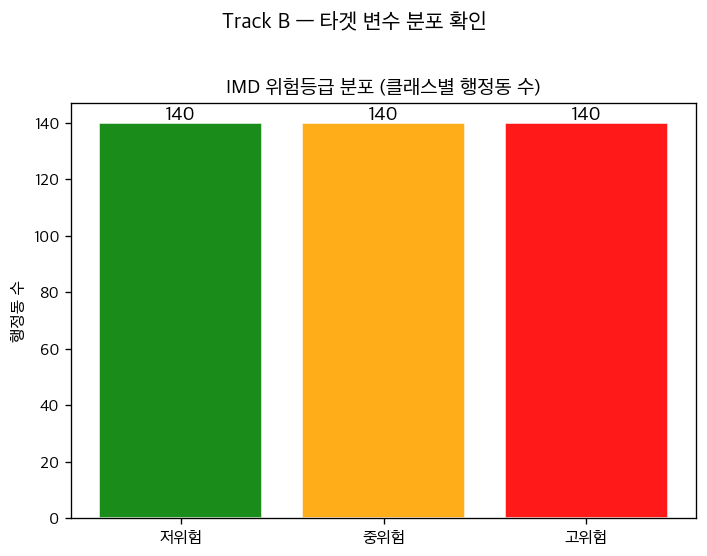

In [48]:
# 클래스 분포 시각화
# 데이터 병합 후 클래스(저, 중, 고)별 행정동 수 확인
fig, ax = plt.subplots(figsize=(6, 4.5))

counts = y_all.value_counts().reindex(CLASS_ORDER)
colors = ['green', 'orange', 'red']
bars = ax.bar(CLASS_ORDER, counts.values, color=colors, edgecolor='white', alpha=0.9)
ax.set_title('IMD 위험등급 분포 (클래스별 행정동 수)', fontsize=12, fontweight='bold')
ax.set_ylabel('행정동 수')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(v), ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Track B — 타겟 변수 분포 확인', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

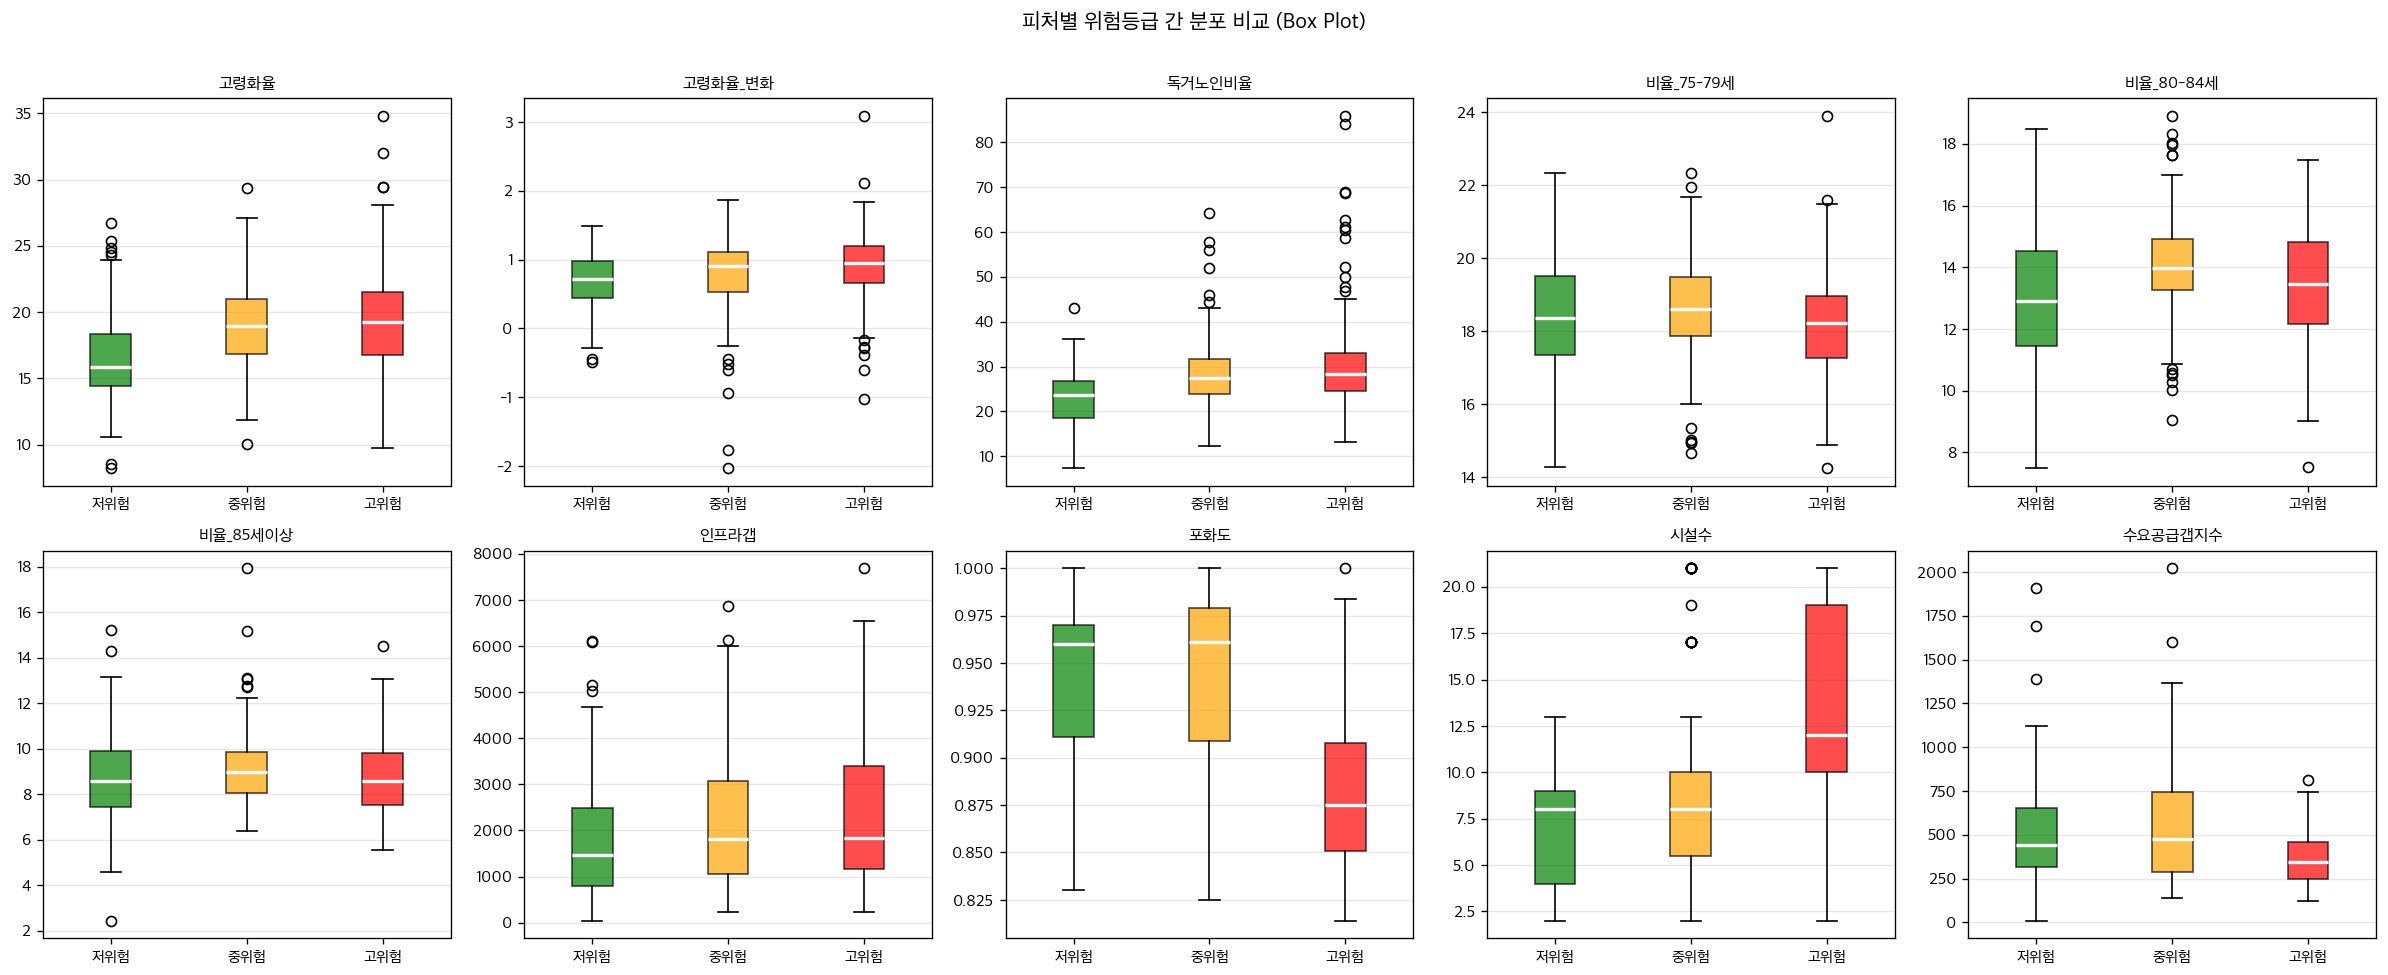

In [49]:
# 피처별 클래스 간 분포 (Box plot)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
colors = ['green', 'orange', 'red']

for i, feat in enumerate(FEAT_COLS):
    data_by_class = [df[df[TARGET] == cls][feat].values for cls in CLASS_ORDER]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                          medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_xticklabels(CLASS_ORDER, fontsize=9)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('피처별 위험등급 간 분포 비교 (Box Plot)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

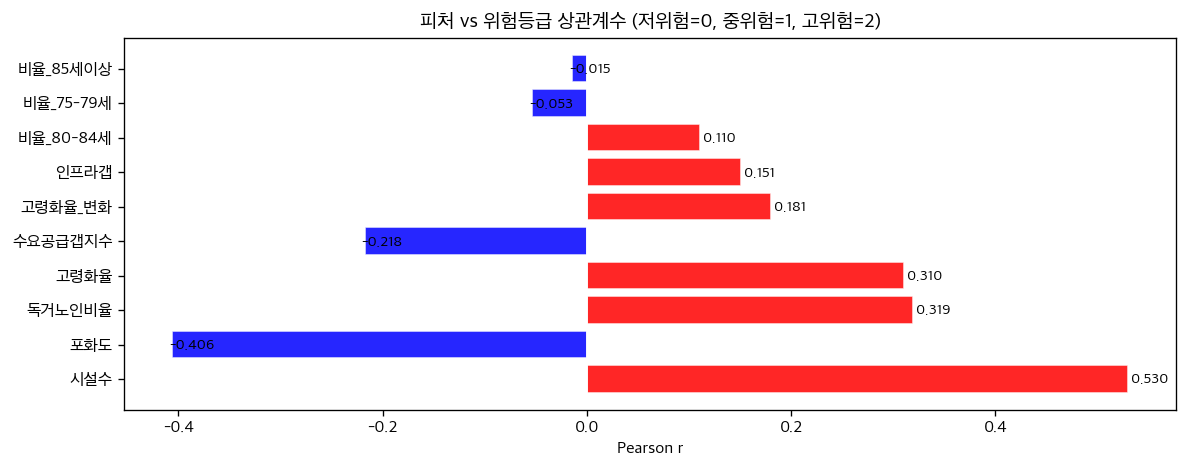


피처-위험등급 상관계수 (절댓값 내림차순):
시설수          0.530093
포화도         -0.406075
독거노인비율       0.319052
고령화율         0.310397
수요공급갭지수     -0.217651
고령화율_변화      0.180656
인프라갭         0.151001
비율_80-84세    0.110355
비율_75-79세   -0.053239
비율_85세이상    -0.014609


In [50]:
# 피처-타겟 상관관계 (클래스를 숫자로 인코딩)
y_num = y_all.cat.codes  # 저위험=0, 중위험=1, 고위험=2
corr_with_y = X_all.corrwith(y_num).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['red' if v > 0 else 'blue' for v in corr_with_y.values]
ax.barh(corr_with_y.index, corr_with_y.values, color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='white', lw=1)
ax.set_title('피처 vs 위험등급 상관계수 (저위험=0, 중위험=1, 고위험=2)', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson r')
for i, (feat, v) in enumerate(zip(corr_with_y.index, corr_with_y.values)):
    ax.text(v + 0.003 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n피처-위험등급 상관계수 (절댓값 내림차순):')
print(corr_with_y.to_string())

---
## 2. 데이터 분할 (8:2 Train/Test Split)

클래스가 균형(각 140개)이므로 **StratifiedShuffleSplit** 효과와 동일하게  
`stratify=y_all` 옵션만으로 train/test에 클래스 비율을 보장한다.

In [51]:
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_all, y_all, meta,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all # train, test에 타겟 변수 비율 일정하게 배분
)

for df_part in [X_train, X_test, y_train, y_test, meta_train, meta_test]:
    df_part.reset_index(drop=True, inplace=True)

print(f'훈련 세트: {len(X_train)}개 행정동')
print(f'테스트 세트: {len(X_test)}개 행정동')

# Train 클래스 분포
print(f'\nTrain 클래스 분포:')
print(y_train.value_counts().reindex(CLASS_ORDER).to_string())

# Test 클래스 분포
print(f'\nTest 클래스 분포:')
print(y_test.value_counts().reindex(CLASS_ORDER).to_string())

훈련 세트: 336개 행정동
테스트 세트: 84개 행정동

Train 클래스 분포:
위험등급
저위험    112
중위험    112
고위험    112

Test 클래스 분포:
위험등급
저위험    28
중위험    28
고위험    28


---
## 3. 헬퍼 함수 및 모델 파이프라인

In [52]:
def eval_clf(y_true, y_pred, y_prob=None, label=''):
    """분류 평가 지표를 딕셔너리로 반환"""
    result = {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Macro_F1' : f1_score(y_true, y_pred, average='macro'),
        'Macro_Precision' : precision_score(y_true, y_pred, average='macro'),
        'Macro_Recall' : recall_score(y_true, y_pred, average='macro'),
    }
    # 예측 확률이 있을 경우, OvR 방식으로 다중 클래스 ROC AUC(매크로 평균)를 계산해 결과에 추가
    # OvR(One-vs-Rest) : 다중 클래스 분류에서 N개의 이진 분류기를 만들어 각각 평가 -> macro로 평균
    if y_prob is not None:
        result['ROC_AUC_OvR'] = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    return result


def build_pipeline(model, scale=True):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


# 모델 파이프라인 정의
# LR, SVM — 스케일링 필수 / RF, XGB — 불필요
MODELS = {
    'LogisticRegression' : build_pipeline(
        LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE), scale=True),
    'SVM_RBF' : build_pipeline(
        SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), scale=True),
    'RandomForest' : build_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), scale=False),
    'XGBoost' : build_pipeline(
        XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1, eval_metric='mlogloss'), scale=False),
}

# XGBoost 레이블 인코딩
# LabelEncoder는 알파벳(가나다) 순 정렬로 의도와 다른 매핑을 생성하므로
# dict 매핑으로 CLASS_ORDER 순서를 명시적으로 보장: 저위험=0, 중위험=1, 고위험=2
class_map = {c: i for i, c in enumerate(CLASS_ORDER)}   # str -> int

# 나중에 예측 결과를 decoding용
inv_map   = {i: c for c, i in class_map.items()}        # int -> str
# print(inv_map)

y_train_enc = y_train.map(class_map)
y_test_enc  = y_test.map(class_map)

print('모델 파이프라인 구성 완료')
print('클래스 인코딩:', class_map)

모델 파이프라인 구성 완료
클래스 인코딩: {'저위험': 0, '중위험': 1, '고위험': 2}


---
## 4. 기본 모델 비교 (CV 없이 — Train/Test 직접 평가)

기본 하이퍼파라미터로 학습·평가해 출발점 성능과 과적합 경향을 확인한다.

In [53]:
baseline_results = []
baseline_preds   = {}

# roc_auc_score는 y_true의 고유값을 알파벳 정렬해 클래스 순서를 결정한다.
# XGBoost prob 컬럼은 class_map 순서(저=0, 중=1, 고=2)이지만
# sklearn은 알파벳 순(고위험, 저위험, 중위험)을 기대 ->  컬럼 재정렬 필요
sorted_labels = sorted(CLASS_ORDER)                       # ['고위험', '저위험', '중위험']
xgb_col_order = [class_map[c] for c in sorted_labels]   # [2, 0, 1]

for name, pipe in MODELS.items():
    m = clone(pipe)
    y_tr = y_train_enc if name == 'XGBoost' else y_train
    y_te = y_test_enc  if name == 'XGBoost' else y_test

    m.fit(X_train, y_tr)
    p_train = m.predict(X_train)
    p_test = m.predict(X_test)
    prob_train = m.predict_proba(X_train)
    prob_test = m.predict_proba(X_test)

    if name == 'XGBoost':
        # 예측값: int -> Categorical 문자열
        p_train = pd.Categorical([inv_map[i] for i in p_train], categories=CLASS_ORDER, ordered=True)
        p_test  = pd.Categorical([inv_map[i] for i in p_test], categories=CLASS_ORDER, ordered=True)

        # prob 컬럼: class_map 순서 -> sklearn 알파벳 순서로 재정렬
        prob_train = prob_train[:, xgb_col_order]
        prob_test = prob_test[:, xgb_col_order]

    tr_metrics = eval_clf(y_train, p_train, prob_train)
    te_metrics = eval_clf(y_test,  p_test,  prob_test)

    baseline_results.append({
        '모델' : name,
        'Train_Acc' : tr_metrics['Accuracy'],
        'Test_Acc' : te_metrics['Accuracy'],
        'Train_F1' : tr_metrics['Macro_F1'],
        'Test_F1' : te_metrics['Macro_F1'],
        'Test_Precision' : te_metrics['Macro_Precision'],
        'Test_Recall' : te_metrics['Macro_Recall'],
        'Test_AUC' : te_metrics.get('ROC_AUC_OvR', np.nan),
        'Overfit_F1' : tr_metrics['Macro_F1'] - te_metrics['Macro_F1'],
    })
    baseline_preds[name] = {'train': p_train, 'test': p_test,
                            'prob_train': prob_train, 'prob_test': prob_test}

df_baseline = pd.DataFrame(baseline_results).sort_values('Test_F1', ascending=False)

print('기본 모델 비교 (기본 하이퍼파라미터)')
print()
print(df_baseline.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

기본 모델 비교 (기본 하이퍼파라미터)

                모델  Train_Acc  Test_Acc  Train_F1  Test_F1  Test_Precision  Test_Recall  Test_AUC  Overfit_F1
           XGBoost     1.0000    0.7381    1.0000   0.7358          0.7358       0.7381    0.8552      0.2642
      RandomForest     1.0000    0.6786    1.0000   0.6752          0.6736       0.6786    0.8510      0.3248
           SVM_RBF     0.7738    0.5952    0.7706   0.5958          0.5973       0.5952    0.7917      0.1748
LogisticRegression     0.6667    0.5595    0.6647   0.5596          0.5645       0.5595    0.7462      0.1052


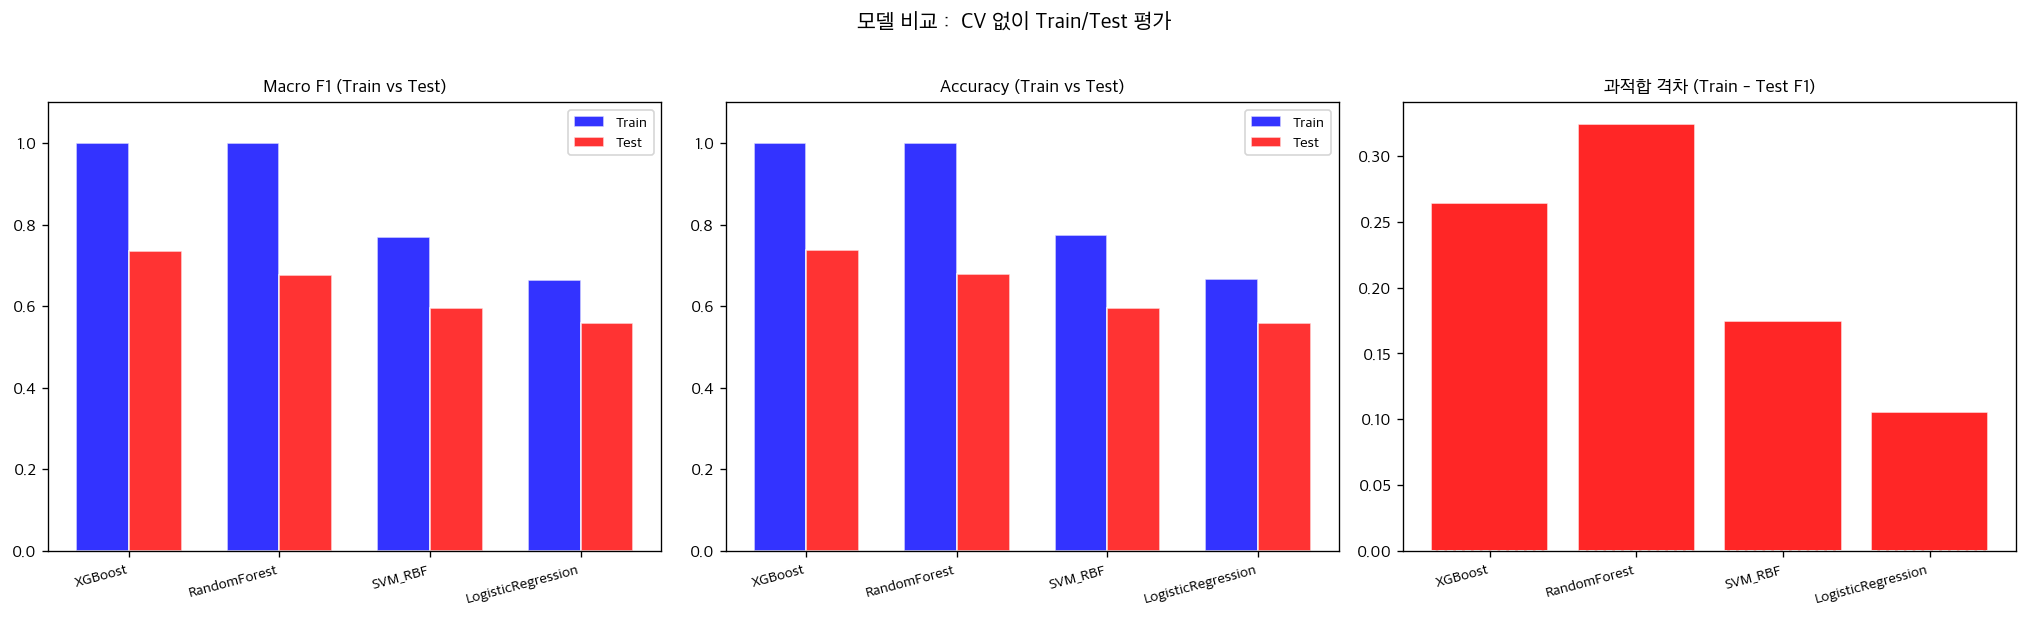

In [54]:
model_names = list(MODELS.keys())
sorted_names = df_baseline['모델'].tolist()
x = np.arange(len(sorted_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Test F1 vs Train F1
for ax, (tr_col, te_col, title) in zip(axes, [
    ('Train_F1', 'Test_F1', 'Macro F1 (Train vs Test)'),
    ('Train_Acc', 'Test_Acc', 'Accuracy (Train vs Test)'),
    ('Overfit_F1', None, '과적합 격차 (Train - Test F1)'),
]):
    if te_col is None:
        vals = [df_baseline[df_baseline['모델'] == n][tr_col].values[0] for n in sorted_names]
        bar_colors = ['red' if v > 0.1 else 'green' for v in vals]
        ax.bar(sorted_names, vals, color=bar_colors, edgecolor='white', alpha=0.85)
        ax.axhline(0, color='white', lw=1, ls='--')
        for i, v in enumerate(vals):
            ax.text(i, v + 0.002, f'{v:+.3f}', ha='center', fontsize=9,
                    color='white', fontweight='bold')
    else:
        tr_v = [df_baseline[df_baseline['모델'] == n][tr_col].values[0] for n in sorted_names]
        te_v = [df_baseline[df_baseline['모델'] == n][te_col].values[0] for n in sorted_names]
        ax.bar(x - width/2, tr_v, width, label='Train', color='blue', alpha=0.8, edgecolor='white')
        ax.bar(x + width/2, te_v, width, label='Test',  color='red', alpha=0.8, edgecolor='white')
        ax.set_xticks(x)
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.1)
        for i, (tr, te) in enumerate(zip(tr_v, te_v)):
            ax.text(i - width/2, tr + 0.01, f'{tr:.3f}', ha='center', fontsize=8, color='white')
            ax.text(i + width/2, te + 0.01, f'{te:.3f}', ha='center', fontsize=8, color='white')
    ax.set_xticklabels(sorted_names, rotation=15, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('모델 비교 :  CV 없이 Train/Test 평가', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 교차검증 성능 비교 (StratifiedKFold-5)

분류 문제이므로 `StratifiedKFold(5)`를 기본 전략으로 사용한다.  
각 fold에서 클래스 비율이 동일하게 유지되어 편향 없는 검증이 가능하다.

In [55]:
cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# sklearn 1.8.0: make_scorer(f1_score, average='macro') 는 multiclass에서 동작 안함
# 문자열 스코어러 또는 response_method 키워드로 교체
CV_SCORING = {
    'F1' : 'f1_macro',
    'Accuracy' : 'accuracy',
    'Precision' : 'precision_macro',
    'Recall' : 'recall_macro',
    'AUC' : make_scorer(roc_auc_score, response_method='predict_proba', multi_class='ovr', average='macro'),
}

cv_results = {}

for name, pipe in MODELS.items():
    y_tr_cv = y_train_enc if name == 'XGBoost' else y_train
    res = cross_validate(
        pipe, X_train, y_tr_cv,
        cv=cv_skf, scoring=CV_SCORING,
        return_train_score=True, n_jobs=-1
    )
    cv_results[name] = res

metrics = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC']
rows = []
for name, res in cv_results.items():
    row = {'Model': name}
    for m in metrics:
        row[f'Val_{m}'] = res[f'test_{m}'].mean()
        row[f'Train_{m}'] = res[f'train_{m}'].mean()
    rows.append(row)

cv_df = pd.DataFrame(rows).set_index('Model')
print(cv_df.to_string(float_format=lambda x: f'{x:.4f}'))

                    Val_F1  Train_F1  Val_Accuracy  Train_Accuracy  Val_Precision  Train_Precision  Val_Recall  Train_Recall  Val_AUC  Train_AUC
Model                                                                                                                                           
LogisticRegression  0.6296    0.6674        0.6309          0.6682         0.6352           0.6688      0.6302        0.6682   0.8214     0.8538
SVM_RBF             0.6410    0.7552        0.6457          0.7582         0.6444           0.7575      0.6457        0.7582   0.8293     0.9216
RandomForest        0.7527    1.0000        0.7558          1.0000         0.7554           1.0000      0.7560        1.0000   0.9018     1.0000
XGBoost             0.7413    1.0000        0.7440          1.0000         0.7467           1.0000      0.7443        1.0000   0.8906     1.0000


In [56]:
# CV 결과 집계 및 비교
cv_summary_rows = []
for name in model_names:
    res = cv_results[name]
    cv_summary_rows.append({
        '모델' : name,
        'Val_F1' : res['test_F1'].mean(),
        'Val_F1_std' : res['test_F1'].std(),
        'Val_Acc' : res['test_Accuracy'].mean(),
        'Val_Precision' : res['test_Precision'].mean(),
        'Val_Recall' : res['test_Recall'].mean(),
        'Val_AUC' : res['test_AUC'].mean(),
        'Train_F1' : res['train_F1'].mean(),
        'Overfit_F1' : res['train_F1'].mean() - res['test_F1'].mean(),
    })

df_cv = pd.DataFrame(cv_summary_rows).sort_values('Val_F1', ascending=False)
print('StratifiedKFold-5 CV 결과 요약')
print()
print(df_cv[['모델', 'Val_F1', 'Val_F1_std', 'Val_Acc',
             'Val_Precision', 'Val_Recall', 'Val_AUC', 'Overfit_F1']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

StratifiedKFold-5 CV 결과 요약

                모델  Val_F1  Val_F1_std  Val_Acc  Val_Precision  Val_Recall  Val_AUC  Overfit_F1
      RandomForest  0.7527      0.0368   0.7558         0.7554      0.7560   0.9018      0.2473
           XGBoost  0.7413      0.0184   0.7440         0.7467      0.7443   0.8906      0.2587
           SVM_RBF  0.6410      0.0412   0.6457         0.6444      0.6457   0.8293      0.1142
LogisticRegression  0.6296      0.0656   0.6309         0.6352      0.6302   0.8214      0.0378


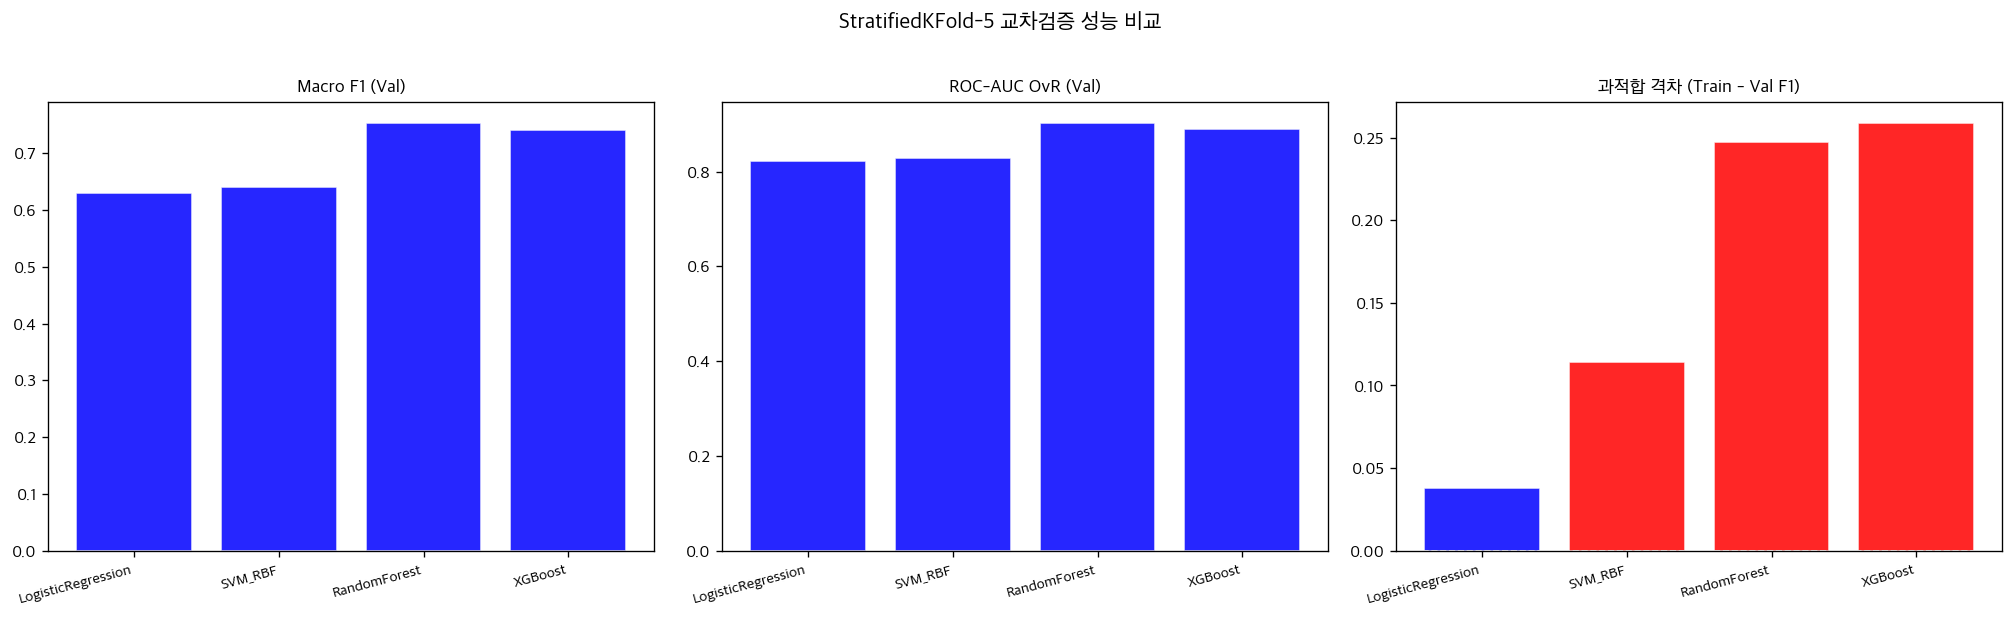

In [57]:
# CV 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metrics = [
    ('Val_F1', 'Val_F1_std', 'Macro F1 (Val)'),
    ('Val_AUC', None, 'ROC-AUC OvR (Val)'),
    ('Overfit_F1', None, '과적합 격차 (Train - Val F1)'),
]

for ax, (col, std_col, title) in zip(axes, metrics):
    vals = [df_cv[df_cv['모델'] == n][col].values[0] for n in model_names]
    errs = None
    if std_col:
        errs = [df_cv[df_cv['모델'] == n][std_col].values[0] for n in model_names]
    bar_colors = ['red' if (col == 'Overfit_F1' and v > 0.1) else 'blue'
                  for v in vals]
    ax.bar(model_names, vals, color=bar_colors, edgecolor='white', alpha=0.85)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    if col == 'Overfit_F1':
        ax.axhline(0, color='white', lw=1, ls='--')
    for i, v in enumerate(vals):
        ax.text(i, (v or 0) + 0.005, f'{v:.3f}', ha='center', fontsize=9,
                color='white', fontweight='bold')

plt.suptitle('StratifiedKFold-5 교차검증 성능 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- 과적합 문제 발생

## 6. 하이퍼파라미터 튜닝 (전 모델 GridSearchCV)

- **Logistic Regression** → `C`, `penalty` 탐색
- **SVM (RBF)** → `C`, `gamma` 탐색
- **Random Forest** → `n_estimators`, `max_depth`, `min_samples_leaf` 탐색
- **XGBoost** → `max_depth`, `learning_rate`, `subsample`, `reg_alpha` 탐색

내부 CV는 `StratifiedKFold(5)`, 평가 지표는 `Macro F1`으로 통일한다.

[Logistic Regression GridSearchCV]
  최적 파라미터: {'model__C': 0.1, 'model__penalty': 'l2'}
  CV Macro F1: 0.6457


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

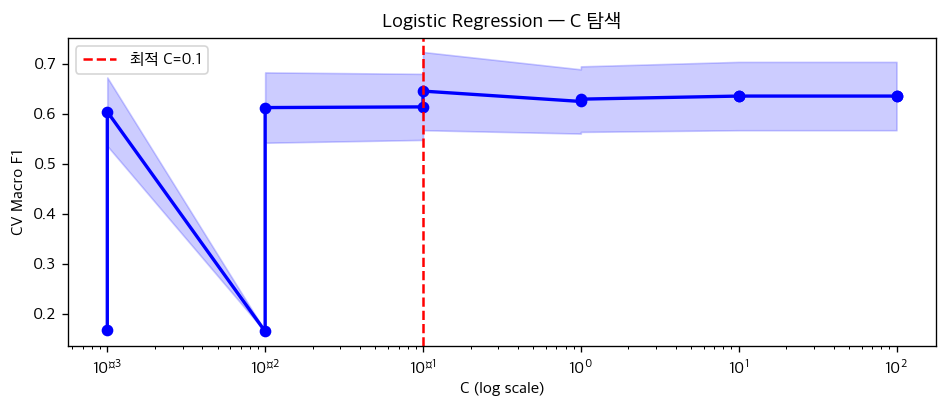


[LR Nested CV — 편향 없는 기대 성능 추정]
Fold scores: [0.6364 0.666  0.6018 0.6402 0.7021]
Mean ± Std : 0.6493 ± 0.0334
(단일 CV 0.6457 vs Nested CV 0.6493 — 차이 = -0.0036)


In [58]:
# sklearn 1.8.0: make_scorer(f1_score, average='macro') 는 multiclass에서 동작 안함 -> 문자열 사용
f1_scorer = 'f1_macro'

# Logistic Regression
print('[Logistic Regression GridSearchCV]')
lr_gs = GridSearchCV(
    build_pipeline(LogisticRegression(max_iter=2000, solver='saga',
                                       random_state=RANDOM_STATE), scale=True),
    {
        'model__C' : [0.001, 0.01, 0.1, 1, 10, 100],
        'model__penalty' : ['l1','l2'],
    },
    cv=cv_skf, scoring=f1_scorer, refit=True, n_jobs=-1
)
lr_gs.fit(X_train, y_train)
print(f'  최적 파라미터: {lr_gs.best_params_}')
print(f'  CV Macro F1: {lr_gs.best_score_:.4f}')

# C vs F1 곡선
fig, ax = plt.subplots(figsize=(8, 3.5))
res = pd.DataFrame(lr_gs.cv_results_)
c_vals = [p['model__C'] for p in res['params']]
means = res['mean_test_score'].values
stds  = res['std_test_score'].values
ax.semilogx(c_vals, means, 'o-', color='blue', lw=2)
ax.fill_between(c_vals, means - stds, means + stds, alpha=0.2, color='blue')
ax.axvline(lr_gs.best_params_['model__C'], color='red', ls='--', lw=1.5,
           label=f'최적 C={lr_gs.best_params_["model__C"]}')
ax.set_title('Logistic Regression — C 탐색', fontsize=12, fontweight='bold')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('CV Macro F1')
ax.legend()
plt.tight_layout()
plt.show()

# Nested CV: LR holdout 성능의 편향 없는 추정
# 단일 GridSearchCV는 검증 fold에 과적합되어 holdout 성능을 과대 추정함을 확인.
# Nested CV(outer 5-fold 안에 inner GridSearchCV)로 보다 정확한 기대 성능을 추정한다.
from sklearn.model_selection import cross_val_score

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + 1)
lr_nested_gs = GridSearchCV(
    build_pipeline(LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE), scale=True),
    {'model__C': [0.001, 0.01, 0.1, 1, 10, 100], 'model__penalty': ['l1', 'l2']},
    cv=cv_skf, scoring=f1_scorer, refit=True, n_jobs=-1
)
nested_scores = cross_val_score(
    lr_nested_gs, X_train, y_train,
    cv=outer_cv, scoring=f1_scorer, n_jobs=1
)
print(f'\n[LR Nested CV — 편향 없는 기대 성능 추정]')
print(f'Fold scores: {nested_scores.round(4)}')
print(f'Mean ± Std : {nested_scores.mean():.4f} ± {nested_scores.std():.4f}')
print(f'(단일 CV {lr_gs.best_score_:.4f} vs Nested CV {nested_scores.mean():.4f} — 차이 = {lr_gs.best_score_ - nested_scores.mean():.4f})')

[SVM RBF GridSearchCV]
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  최적 파라미터: {'model__C': 10, 'model__gamma': 'scale'}
  CV Macro F1: 0.6680


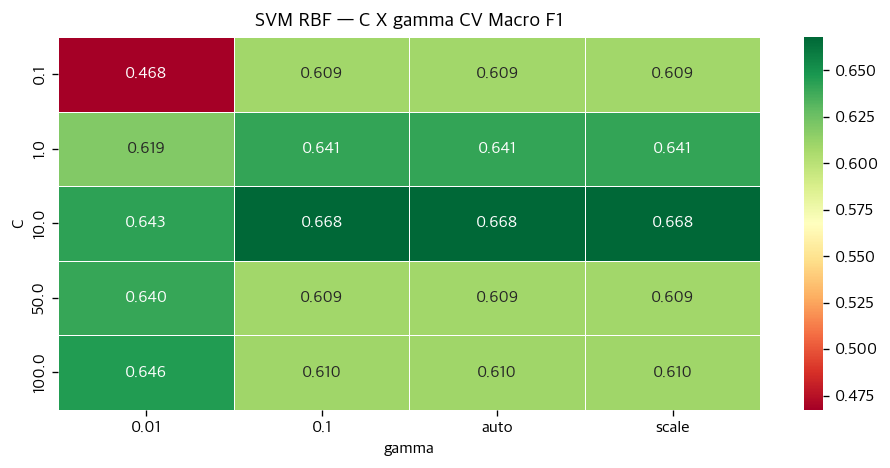

In [59]:
# SVM (RBF Kernel)
print('[SVM RBF GridSearchCV]')
svm_gs = GridSearchCV(
    build_pipeline(SVC(kernel='rbf', probability=True,
                        random_state=RANDOM_STATE), scale=True),
    {
        'model__C' : [0.1, 1, 10, 50, 100],
        'model__gamma': ['scale', 'auto', 0.01, 0.1],
    },
    cv=cv_skf, scoring=f1_scorer, refit=True, n_jobs=-1, verbose=1
)
svm_gs.fit(X_train, y_train)
print(f'  최적 파라미터: {svm_gs.best_params_}')
print(f'  CV Macro F1: {svm_gs.best_score_:.4f}')

# C × gamma 히트맵 — gamma 값을 문자열로 통일해서 pivot_table 혼합 타입 오류 방지
svm_res = pd.DataFrame(svm_gs.cv_results_)
svm_res['gamma_str'] = svm_res['param_model__gamma'].astype(str)
svm_pivot = svm_res.pivot_table(
    index='param_model__C',
    columns='gamma_str',
    values='mean_test_score',
    aggfunc='mean'
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(svm_pivot.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, linewidths=0.5)
ax.set_title('SVM RBF — C X gamma CV Macro F1', fontsize=12, fontweight='bold')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.show()

In [60]:
# Random Forest Classifier
# 기존 그리드: max_depth=None 포함, min_samples_leaf 최대 4 -> Train F1=1.0 과적합
# 수정: max_depth=None 제거, min_samples_leaf 상향, min_impurity_decrease 추가
print('[Random Forest GridSearchCV]')
rf_gs = GridSearchCV(
    build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), scale=False),
    {
        'model__n_estimators' : [200, 300],
        'model__max_depth' : [3, 5, 7, 10],        # None 제거 — 완전 성장 방지
        'model__min_samples_leaf' : [3, 5, 8, 12],        # 최솟값 1->3 상향
        'model__max_features' : ['sqrt', 0.5],
        'model__min_impurity_decrease' : [0.0, 0.005, 0.01],   # 분할 최소 불순도 감소량
    },
    cv=cv_skf, scoring=f1_scorer, refit=True, n_jobs=-1, verbose=1
)
rf_gs.fit(X_train, y_train)
print(f'  CV Macro F1: {rf_gs.best_score_:.4f}')
print(pd.DataFrame(rf_gs.best_params_.items(), columns=['파라미터', '최적값']).to_string(index=False))

[Random Forest GridSearchCV]
Fitting 5 folds for each of 192 candidates, totalling 960 fits
  CV Macro F1: 0.7538
                        파라미터   최적값
            model__max_depth   7.0
         model__max_features   0.5
model__min_impurity_decrease   0.0
     model__min_samples_leaf   5.0
         model__n_estimators 300.0


In [61]:
# XGBoost Classifier
# reg_lambda(L2) 추가: reg_alpha(L1)만으로는 부족한 가중치 정규화를 보완
# max_depth: 336개 샘플 기준 7은 과도하므로 [3, 5]로 제한
print('[XGBoost Classifier GridSearchCV]')
xgb_gs = GridSearchCV(
    build_pipeline(
        XGBClassifier(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
                      eval_metric='mlogloss'), scale=False),
    {
        'model__n_estimators' : [100, 200, 300],
        'model__max_depth' : [3, 5],              # 7 제거 — 소규모 데이터에서 과적합
        'model__learning_rate' : [0.05, 0.1, 0.2],
        'model__subsample' : [0.8, 1.0],
        'model__colsample_bytree' : [0.8, 1.0],
        'model__reg_alpha' : [0, 0.1, 1],
        'model__reg_lambda' : [1, 2, 5],           # L2 정규화 추가
    },
    cv=cv_skf, scoring=f1_scorer, refit=True, n_jobs=-1, verbose=1
)
xgb_gs.fit(X_train, y_train_enc)
print(f'  CV Macro F1: {xgb_gs.best_score_:.4f}')
print(pd.DataFrame(xgb_gs.best_params_.items(), columns=['파라미터', '최적값']).to_string(index=False))

[XGBoost Classifier GridSearchCV]
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
  CV Macro F1: 0.7758
                   파라미터    최적값
model__colsample_bytree   0.80
   model__learning_rate   0.05
       model__max_depth   3.00
    model__n_estimators 200.00
       model__reg_alpha   0.10
      model__reg_lambda   2.00
       model__subsample   1.00


In [62]:
TUNED_MODELS = {
    'LogisticRegression' : lr_gs.best_estimator_,
    'SVM_RBF' : svm_gs.best_estimator_,
    'RandomForest' : rf_gs.best_estimator_,
    'XGBoost' : xgb_gs.best_estimator_,
}

tuning_summary = pd.DataFrame([
    {'모델': 'LogisticRegression',
     'CV_F1': lr_gs.best_score_,
     '최적파라미터': str(lr_gs.best_params_)},
    {'모델': 'SVM_RBF',
     'CV_F1': svm_gs.best_score_,
     '최적파라미터': str(svm_gs.best_params_)},
    {'모델': 'RandomForest',
     'CV_F1': rf_gs.best_score_,
     '최적파라미터': str(rf_gs.best_params_)},
    {'모델': 'XGBoost',
     'CV_F1': xgb_gs.best_score_,
     '최적파라미터': str(xgb_gs.best_params_)}
]).sort_values('CV_F1', ascending=False).reset_index(drop=True)

display(tuning_summary.style
    .format({'CV_F1': '{:.4f}'})
    .set_properties(subset=['최적파라미터'], **{'text-align': 'left'})
    .set_caption('GridSearchCV 튜닝 결과 요약 (Macro F1 기준)'))

,모델,CV_F1,최적파라미터
0,XGBoost,0.7758,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__reg_alpha': 0.1, 'model__reg_lambda': 2, 'model__subsample': 1.0}"
1,RandomForest,0.7538,"{'model__max_depth': 7, 'model__max_features': 0.5, 'model__min_impurity_decrease': 0.0, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}"
2,SVM_RBF,0.6680,"{'model__C': 10, 'model__gamma': 'scale'}"
3,LogisticRegression,0.6457,"{'model__C': 0.1, 'model__penalty': 'l2'}"


---
## 7. 최종 모델 평가 (Holdout Test Set)

In [63]:
print('[최종 모델 — Holdout Test Set 평가]')
print()

test_results = []
test_preds = {}
test_probs = {}

# XGBoost prob 컬럼 재정렬 인덱스 (class_map 순 -> sklearn 알파벳 순)
# 앞의 8 : 2 단일 분할과 동일한 로직
sorted_labels = sorted(CLASS_ORDER)                       # ['고위험', '저위험', '중위험']
xgb_col_order = [class_map[c] for c in sorted_labels]   # [2, 0, 1]

for name, model in TUNED_MODELS.items():
    p_train = model.predict(X_train)
    p_test = model.predict(X_test)
    prob_train = model.predict_proba(X_train)
    prob_test  = model.predict_proba(X_test)

    if name == 'XGBoost':
        p_train = pd.Categorical([inv_map[i] for i in p_train],
                                  categories=CLASS_ORDER, ordered=True)
        p_test  = pd.Categorical([inv_map[i] for i in p_test],
                                  categories=CLASS_ORDER, ordered=True)
        prob_train = prob_train[:, xgb_col_order]
        prob_test = prob_test[:,  xgb_col_order]

    tr_m = eval_clf(y_train, p_train, prob_train)
    te_m = eval_clf(y_test, p_test, prob_test)

    test_results.append({
        '모델' : name,
        'Train_F1' : tr_m['Macro_F1'],
        'Test_F1' : te_m['Macro_F1'],
        'Test_Acc' : te_m['Accuracy'],
        'Test_Precision' : te_m['Macro_Precision'],
        'Test_Recall' : te_m['Macro_Recall'],
        'Test_AUC' : te_m.get('ROC_AUC_OvR', np.nan),
        'Overfit_F1' : tr_m['Macro_F1'] - te_m['Macro_F1'],
    })
    test_preds[name] = p_test
    test_probs[name] = prob_test

df_test = pd.DataFrame(test_results).sort_values('Test_F1', ascending=False).reset_index(drop=True)
print(df_test.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

BEST_MODEL_NAME = df_test.iloc[0]['모델']
print(f'\n최적 모델: {BEST_MODEL_NAME} | Test Macro F1={df_test.iloc[0]["Test_F1"]:.4f} | Test AUC={df_test.iloc[0]["Test_AUC"]:.4f}')

[최종 모델 — Holdout Test Set 평가]

                모델  Train_F1  Test_F1  Test_Acc  Test_Precision  Test_Recall  Test_AUC  Overfit_F1
           XGBoost    0.9911   0.7496    0.7500          0.7532       0.7500    0.8750      0.2415
           SVM_RBF    0.9221   0.6570    0.6548          0.6610       0.6548    0.8355      0.2652
      RandomForest    0.8954   0.6530    0.6548          0.6515       0.6548    0.8272      0.2424
LogisticRegression    0.6375   0.5333    0.5357          0.5361       0.5357    0.7449      0.1042

최적 모델: XGBoost | Test Macro F1=0.7496 | Test AUC=0.8750


---
## 8. 혼동 행렬 (3×3 Confusion Matrix)

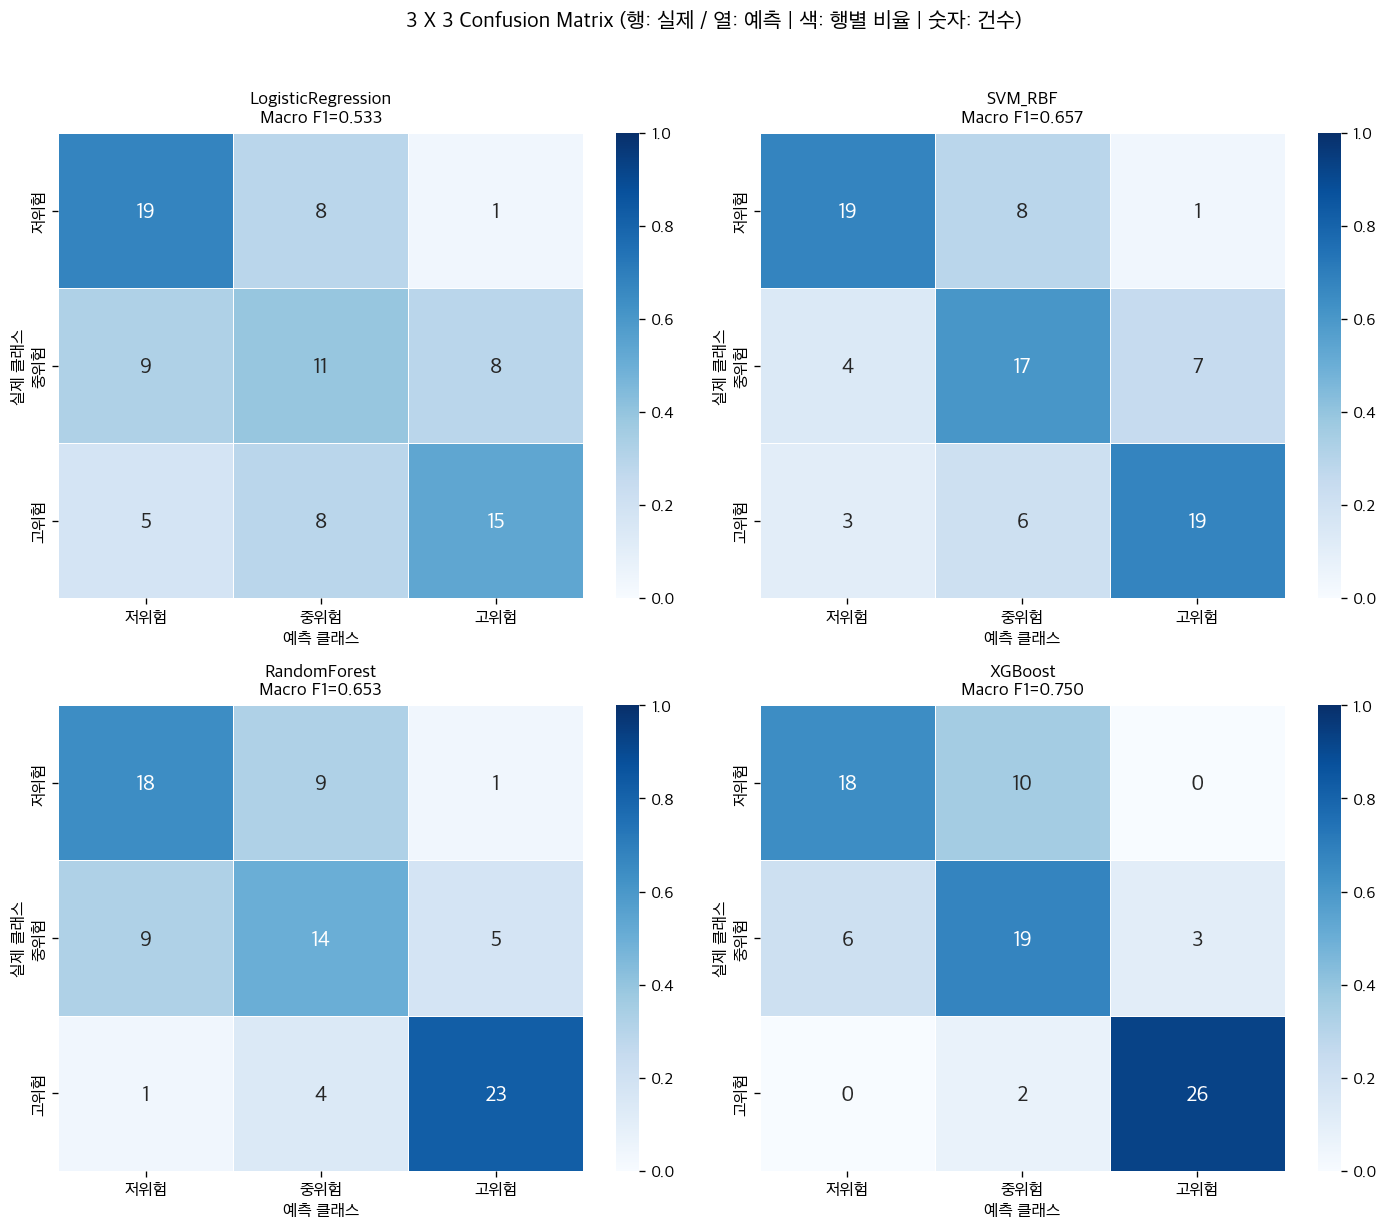


[XGBoost — Classification Report]
              precision    recall  f1-score   support

         저위험     0.8966    0.9286    0.9123        28
         중위험     0.7500    0.6429    0.6923        28
         고위험     0.6129    0.6786    0.6441        28

    accuracy                         0.7500        84
   macro avg     0.7532    0.7500    0.7496        84
weighted avg     0.7532    0.7500    0.7496        84



In [64]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, name in zip(axes, TUNED_MODELS.keys()):
    cm = confusion_matrix(y_test, test_preds[name], labels=CLASS_ORDER)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                ax=ax, linewidths=0.5, vmin=0, vmax=1,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'{name}\nMacro F1={df_test[df_test["모델"]==name]["Test_F1"].values[0]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('예측 클래스')
    ax.set_ylabel('실제 클래스')

plt.suptitle('3 X 3 Confusion Matrix (행: 실제 / 열: 예측 | 색: 행별 비율 | 숫자: 건수)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 최적 모델 classification report
print(f'\n[{BEST_MODEL_NAME} — Classification Report]')
print(classification_report(y_test, test_preds[BEST_MODEL_NAME], target_names=CLASS_ORDER, digits=4))

---
## 9. 학습 곡선 (Learning Curve)

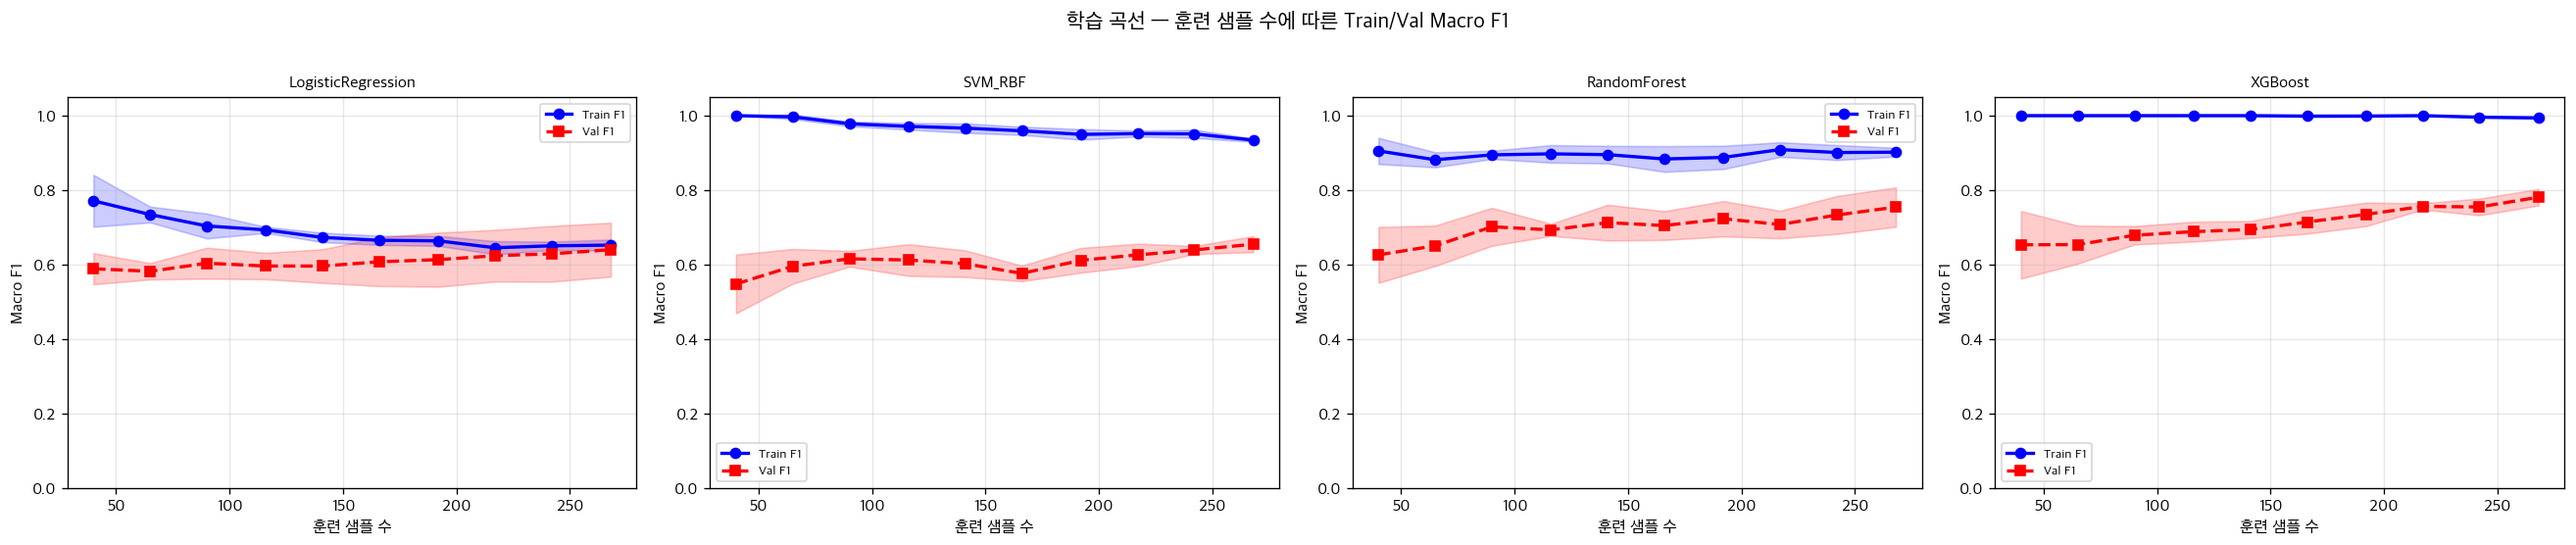

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

for ax, (name, model) in zip(axes, TUNED_MODELS.items()):
    y_lc = y_train_enc if name == 'XGBoost' else y_train
    train_sizes, train_sc, val_sc = learning_curve(
        model, X_train, y_lc,
        train_sizes=np.linspace(0.15, 1.0, 10),
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring=f1_scorer, n_jobs=-1
    )
    tr_mean = train_sc.mean(axis=1);  tr_std = train_sc.std(axis=1)
    va_mean = val_sc.mean(axis=1);    va_std = val_sc.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='blue', lw=2, label='Train F1')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.2, color='blue')
    ax.plot(train_sizes, va_mean, 's--', color='red', lw=2, label='Val F1')
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                    alpha=0.2, color='red')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('훈련 샘플 수')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('학습 곡선 — 훈련 샘플 수에 따른 Train/Val Macro F1',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10. 피처 중요도 분석 (SHAP)

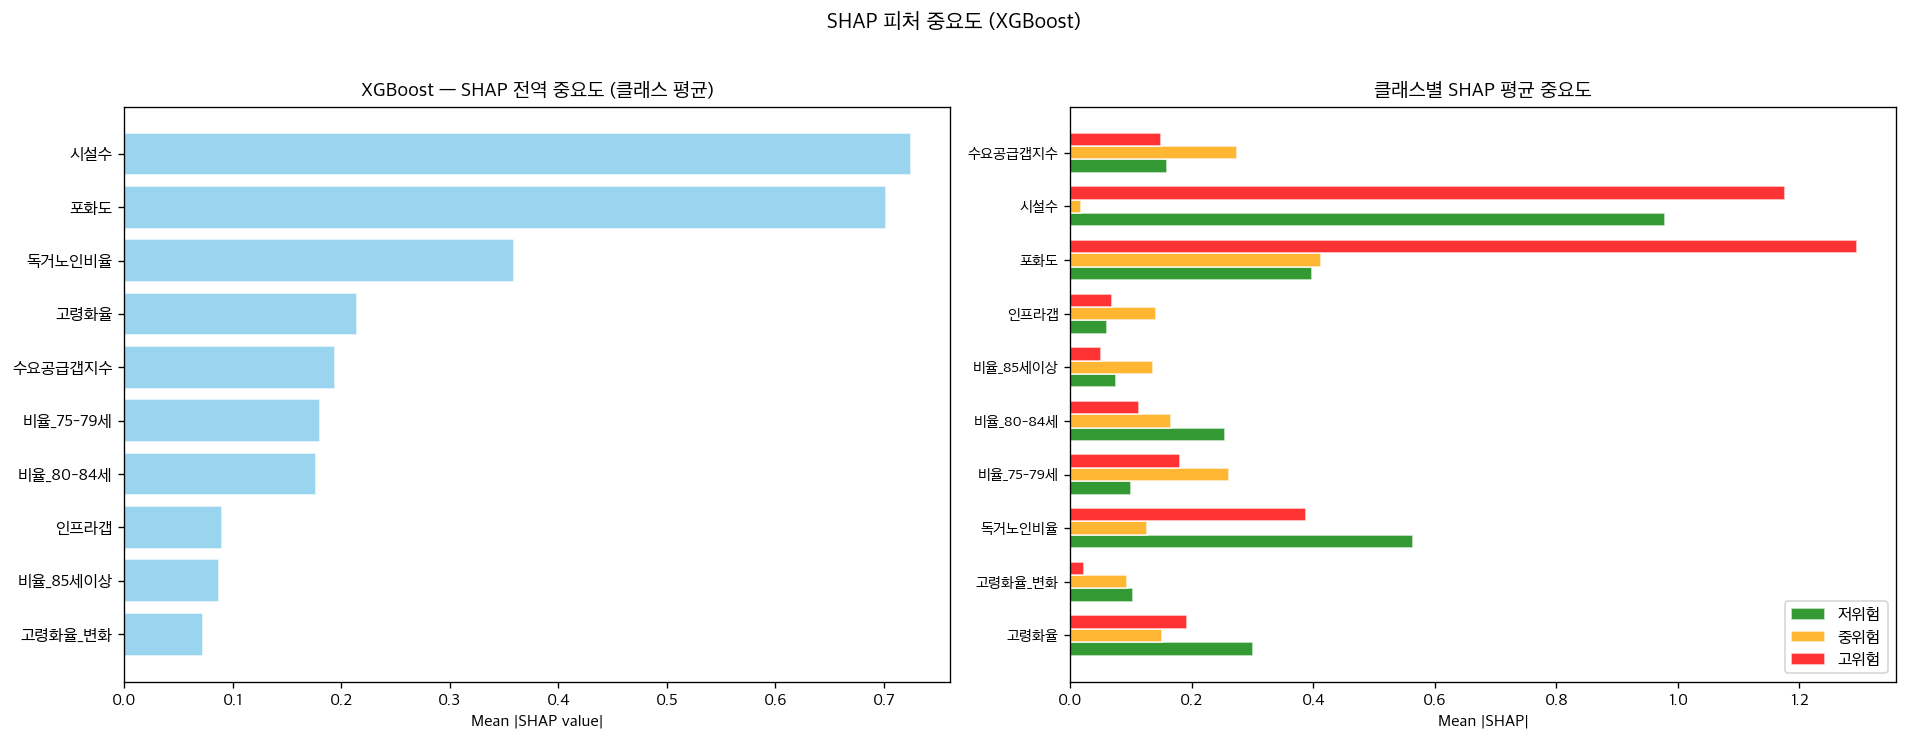


[SHAP 피처 중요도 순위 (클래스 평균)]
       피처  Mean |SHAP|
      시설수     0.724622
      포화도     0.702077
   독거노인비율     0.358798
     고령화율     0.214093
  수요공급갭지수     0.194039
비율_75-79세     0.180292
비율_80-84세     0.176952
     인프라갭     0.089662
 비율_85세이상     0.087038
  고령화율_변화     0.072729


In [66]:
best_model = TUNED_MODELS[BEST_MODEL_NAME]

try:
    import shap

    # Pipeline에서 코어 모델과 변환된 X 추출
    if hasattr(best_model, 'named_steps'):
        step_keys  = list(best_model.named_steps.keys())
        core_model = best_model.named_steps[step_keys[-1]]
        if 'scaler' in best_model.named_steps:
            X_tr_t = pd.DataFrame(
                best_model.named_steps['scaler'].transform(X_train), columns=FEAT_COLS)
            X_te_t = pd.DataFrame(
                best_model.named_steps['scaler'].transform(X_test),  columns=FEAT_COLS)
        else:
            X_tr_t, X_te_t = X_train.copy(), X_test.copy()
    else:
        core_model = best_model
        X_tr_t, X_te_t = X_train.copy(), X_test.copy()

    model_type = type(core_model).__name__
    if any(t in model_type for t in ['XGB', 'Forest', 'Tree']):
        explainer = shap.TreeExplainer(core_model)
        shap_values = explainer.shap_values(X_te_t)
    else:
        explainer = shap.LinearExplainer(core_model, X_tr_t)
        shap_values = explainer.shap_values(X_te_t)

    # shap 0.51+: shap_values()가 3D ndarray (samples, features, classes)를 반환
    # 구버전(< 0.41): list of 2D arrays 반환 — 두 경우 모두 처리
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # 신버전: (84, 10, 3) -> 클래스 축 평균
        mean_abs = np.abs(shap_values).mean(axis=(0, 2))   # (10,) 피처별 전체 평균
        class_mean_abs = [np.abs(shap_values[:, :, i]).mean(axis=0)
                          for i in range(shap_values.shape[2])]
    elif isinstance(shap_values, list):
        # 구버전: list of (84, 10) arrays
        mean_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
        class_mean_abs = [np.abs(sv).mean(axis=0) for sv in shap_values]
    else:
        mean_abs = np.abs(shap_values).mean(axis=0)
        class_mean_abs = None

    class_colors = ['green', 'orange', 'red']  # 저위험, 중위험, 고위험
    shap_df = pd.DataFrame({'피처': FEAT_COLS, 'Mean |SHAP|': mean_abs}).sort_values('Mean |SHAP|')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 전역 중요도 막대
    axes[0].barh(shap_df['피처'], shap_df['Mean |SHAP|'],
                 color='skyblue',
                 edgecolor='white', alpha=0.85)

    axes[0].set_title(f'{BEST_MODEL_NAME} — SHAP 전역 중요도 (클래스 평균)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Mean |SHAP value|')

    # 클래스별 중요도
    if class_mean_abs is not None and len(class_mean_abs) == 3:
        x_pos = np.arange(len(FEAT_COLS))
        w = 0.25
        for i, (cls, color) in enumerate(zip(CLASS_ORDER, class_colors)):
            axes[1].barh(x_pos + i * w, class_mean_abs[i], w, label=cls, color=color, alpha=0.8, edgecolor='white')
        axes[1].set_yticks(x_pos + w)
        axes[1].set_yticklabels(FEAT_COLS, fontsize=9)
        axes[1].set_title('클래스별 SHAP 평균 중요도', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Mean |SHAP|')
        axes[1].legend()
    else:
        plt.sca(axes[1])
        shap.summary_plot(shap_values, X_te_t, feature_names=FEAT_COLS,
                          show=False, plot_type='dot', max_display=10)
        axes[1].set_title('SHAP Beeswarm', fontsize=12, fontweight='bold')

    plt.suptitle(f'SHAP 피처 중요도 ({BEST_MODEL_NAME})', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print('\n[SHAP 피처 중요도 순위 (클래스 평균)]')
    print(shap_df.sort_values('Mean |SHAP|', ascending=False).to_string(index=False))

except Exception as e:
    print(f'SHAP 오류: {e}')
    if hasattr(core_model, 'feature_importances_'):
        fi_df = pd.DataFrame({'피처': FEAT_COLS,
                              '중요도': core_model.feature_importances_}).sort_values('중요도', ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(fi_df['피처'][::-1], fi_df['중요도'][::-1], color='blue', edgecolor='white', alpha=0.85)
        ax.set_title(f'{BEST_MODEL_NAME} — sklearn Feature Importance', fontsize=12, fontweight='bold')
        ax.set_xlabel('Feature Importance')
        plt.tight_layout()
        plt.show()
        print(fi_df.to_string(index=False))

---
## 11. 최종 결과 요약

최종 모델 성능 요약 (StratifiedKFold-5 CV + Holdout Test)


,모델,CV F1 (±std),CV AUC,Test F1,Test Acc,Test AUC,과적합 F1 갭
0,LogisticRegression,0.630 ± 0.066,0.821,0.533,0.536,0.745,+0.104
1,SVM_RBF,0.641 ± 0.041,0.829,0.657,0.655,0.835,+0.265
2,RandomForest,0.753 ± 0.037,0.902,0.653,0.655,0.827,+0.242
3,XGBoost,0.741 ± 0.018,0.891,0.750,0.750,0.875,+0.242


지표,값
Test Macro F1,0.7496
Test Accuracy,0.7500
Test Macro AUC,0.8750
Test Precision,0.7532
Test Recall,0.7500


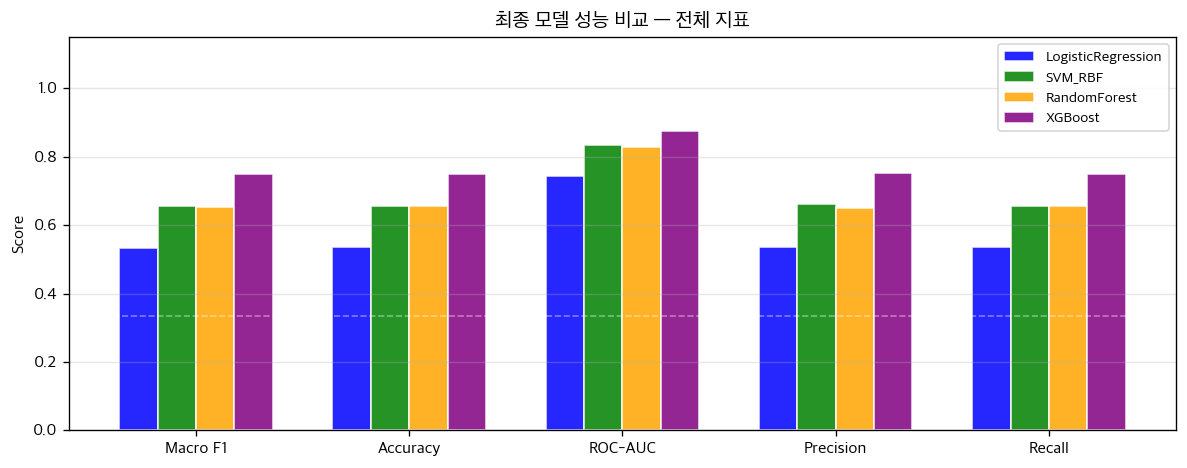

In [67]:
print('최종 모델 성능 요약 (StratifiedKFold-5 CV + Holdout Test)')

final_rows = []
for name in model_names:
    cv_r = cv_results[name]
    t_row = df_test[df_test['모델'] == name].iloc[0]
    cv_f1 = cv_r['test_F1'].mean()
    cv_f1_std = cv_r['test_F1'].std()
    cv_auc = cv_r['test_AUC'].mean()
    final_rows.append({
        '모델' : name,
        'CV F1 (±std)' : f'{cv_f1:.3f} ± {cv_f1_std:.3f}',
        'CV AUC' : f'{cv_auc:.3f}',
        'Test F1' : f'{t_row["Test_F1"]:.3f}',
        'Test Acc' : f'{t_row["Test_Acc"]:.3f}',
        'Test AUC' : f'{t_row["Test_AUC"]:.3f}',
        '과적합 F1 갭' : f'{t_row["Overfit_F1"]:+.3f}',
    })

final_df = pd.DataFrame(final_rows)
display(final_df.style.set_caption('StratifiedKFold-5 CV'))

row = df_test[df_test['모델'] == BEST_MODEL_NAME].iloc[0]
best_summary = pd.DataFrame([{
    '지표' : metric,
    '값' : f'{row[col]:.4f}',
} for metric, col in [
    ('Test Macro F1', 'Test_F1'),
    ('Test Accuracy', 'Test_Acc'),
    ('Test Macro AUC', 'Test_AUC'),
    ('Test Precision', 'Test_Precision'),
    ('Test Recall', 'Test_Recall'),
]])

display(best_summary.style.hide(axis='index').set_caption(f'최적 모델: {BEST_MODEL_NAME}'))

# 최적 모델 시각화 요약 막대
fig, ax = plt.subplots(figsize=(10, 4))
metrics_plot = ['Test_F1', 'Test_Acc', 'Test_AUC', 'Test_Precision', 'Test_Recall']
labels_plot = ['Macro F1', 'Accuracy', 'ROC-AUC', 'Precision', 'Recall']
x = np.arange(len(metrics_plot))
width = 0.18
palette = ['blue', 'green', 'orange', 'purple', 'skyblue']

for i, (name, color) in enumerate(zip(list(TUNED_MODELS.keys()), palette)):
    vals = [df_test[df_test['모델'] == name][m].values[0] for m in metrics_plot]
    bars = ax.bar(x + (i - 1.5) * width, vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('최종 모델 성능 비교 — 전체 지표', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.axhline(1/3, color='white', lw=1, ls='--', alpha=0.4, label='Random Baseline (0.333)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- 대부분의 지표에서 XGB 모델이 가장 우수한 성능을 나타내고 있음.
    - 아무래도 다중 분류 모델에서 LR 모델은 성능이 뛰어지는 않은 것으로 보임.